GPU check and library Installation

In [1]:
# Check GPU availability and install Ultralytics
!nvidia-smi
!pip install -q ultralytics

Mon Aug 17 16:03:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

uploading the zip


In [2]:
from google.colab import files
import zipfile
import os

# Prompt file upload from local machine
print("Please select your nepali_dal_bhat_dataset.zip file:")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

# Extract directly into Colab runtime storage
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Dataset uploaded and extracted successfully to /content!")

Please select your nepali_dal_bhat_dataset.zip file:


Saving nepali_dal_bhat_dataset.zip to nepali_dal_bhat_dataset (1).zip
Dataset uploaded and extracted successfully to /content!


run this this will overwrite the data.ymal in your zip file as it is most likely has a faulty path

In [4]:
import yaml

# Overwrite data.yaml with Colab-compatible paths
yaml_content = {
    'path': '/content/nepali_dal_bhat_dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'bhat',
        1: 'dal',
        2: 'sabji'
    }
}

with open('/content/nepali_dal_bhat_dataset/data.yaml', 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print("data.yaml updated with Colab paths successfully!")

data.yaml updated with Colab paths successfully!


train yolov8 with advanced data agumentation

In [5]:
from ultralytics import YOLO

# Load lightweight segmentation model (~7MB)
model = YOLO("yolov8n-seg.pt")

# Train with aggressive data augmentations
results = model.train(
    data="/content/nepali_dal_bhat_dataset/data.yaml",
    task="segment",
    epochs=100,             # High epoch count for small dataset convergence
    imgsz=640,
    batch=16,

    # Advanced Data Augmentations
    augment=True,
    hsv_h=0.015,            # Color hue variation
    hsv_s=0.7,              # Saturation variation
    hsv_v=0.4,              # Brightness variation
    degrees=15.0,           # Random rotations
    translate=0.1,          # Image translation
    scale=0.5,              # Random scaling
    shear=2.0,              # Geometric shear
    perspective=0.0005,     # Perspective transform
    flipud=0.5,             # Vertical flip
    fliplr=0.5,             # Horizontal flip
    mosaic=1.0,             # Mosaic augmentation (combines 4 images into 1)
    mixup=0.1,              # Blends images together

    # Save training output locally in Colab runtime
    project="/content/runs/segment",
    name="nepali_plate_run"
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/nepali_dal_bhat_dataset/data.yaml, degrees=15.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nepali_plate_r

this below fucntoin inferences on test images and calcualtes the exact segmented area in pixels and relative plate percentage for bhat, dal and sabji

In [7]:
import glob

# Search for best.pt inside /content/runs
found_weights = glob.glob("/content/runs/**/best.pt", recursive=True)

if found_weights:
    print("Found best.pt at:")
    for path in found_weights:
        print(path)
else:
    print("best.pt was not found. Please verify if model.train() finished running successfully.")

Found best.pt at:
/content/runs/segment/nepali_plate_run-2/weights/best.pt


In [8]:
import cv2
import glob
import numpy as np
import os
from ultralytics import YOLO

# Dynamically pick the generated best.pt path
weights = glob.glob("/content/runs/**/best.pt", recursive=True)

if not weights:
    raise FileNotFoundError("Training has not finished or best.pt does not exist yet. Run model.train() first.")

best_model_path = weights[0]
print(f"Loading weights from: {best_model_path}")
model = YOLO(best_model_path)

def analyze_plate(image_path):
    results = model.predict(source=image_path, conf=0.25, task="segment")
    result = results[0]

    img_height, img_width = result.orig_shape

    summary = {
        "bhat": {"pixel_count": 0, "percentage": 0.0},
        "dal": {"pixel_count": 0, "percentage": 0.0},
        "sabji": {"pixel_count": 0, "percentage": 0.0}
    }

    if result.masks is not None:
        masks = result.masks.data.cpu().numpy()  # shape: (N, H, W)
        class_ids = result.boxes.cls.cpu().numpy().astype(int)

        for mask, cls_id in zip(masks, class_ids):
            class_name = result.names[cls_id]

            # Resize binary mask to original image dimensions
            resized_mask = cv2.resize(mask, (img_width, img_height))
            binary_mask = (resized_mask > 0.5).astype(np.uint8)

            # Count positive mask pixels
            pixel_area = int(np.sum(binary_mask))

            if class_name in summary:
                summary[class_name]["pixel_count"] += pixel_area

        # Calculate percentage distribution across plate
        total_food_pixels = sum(item["pixel_count"] for item in summary.values())
        if total_food_pixels > 0:
            for item in summary:
                summary[item]["percentage"] = round((summary[item]["pixel_count"] / total_food_pixels) * 100, 2)

    return summary

# Test execution on a validation image
val_dir = "/content/nepali_dal_bhat_dataset/images/val"
sample_img = os.path.join(val_dir, os.listdir(val_dir)[0])
food_payload = analyze_plate(sample_img)

print("\nSegmented Quantities Payload for Downstream Module:")
print(food_payload)

Loading weights from: /content/runs/segment/nepali_plate_run-2/weights/best.pt

image 1/1 /content/nepali_dal_bhat_dataset/images/val/a5d6bb0a-dal_bhat16_jpg.rf.pmVMxyOrEK0GWVNvGfj2.jpg: 640x608 1 bhat, 2 dals, 2 sabjis, 31.4ms
Speed: 8.1ms preprocess, 31.4ms inference, 23.6ms postprocess per image at shape (1, 3, 640, 608)

Segmented Quantities Payload for Downstream Module:
{'bhat': {'pixel_count': 171682, 'percentage': 38.21}, 'dal': {'pixel_count': 159611, 'percentage': 35.53}, 'sabji': {'pixel_count': 117995, 'percentage': 26.26}}


downling trained weights

In [10]:
import glob
from google.colab import files

# Search for best.pt dynamically
found_weights = glob.glob("/content/runs/**/best.pt", recursive=True)

if found_weights:
    target_weight = found_weights[0]
    print(f"Found model weights at: {target_weight}")
    print("Initiating download...")
    files.download(target_weight)
else:
    print("❌ Could not find 'best.pt'. Please ensure your model.train() cell ran and completed successfully.")

Found model weights at: /content/runs/segment/nepali_plate_run-2/weights/best.pt
Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Evaluation


Loading weights from: /content/runs/segment/nepali_plate_run-2/weights/best.pt

Upload an image from your device to test segmentation:


Saving 28.jpg to 28.jpg

image 1/1 /content/28.jpg: 640x640 1 bhat, 1 dal, 7 sabjis, 9.0ms
Speed: 2.9ms preprocess, 9.0ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


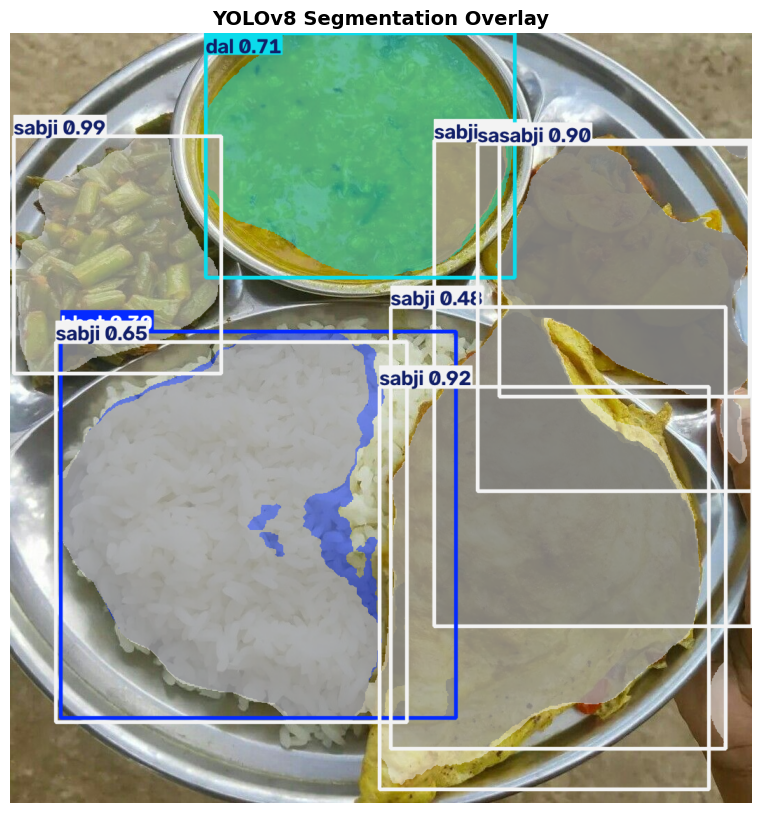


      EVALUATION METRICS & SEGMENTATION BREAKDOWN
Original Image Dimensions : 1059x1100 (1,164,900 total pixels)
Total Food Area Segmented : 1,360,860 pixels

Class      | Detections | Confidence   | Pixel Area   | Plate Share (%)
--------------------------------------------------------------------
bhat       | 1          | 29.7%        | 183,043      | 13.45%
dal        | 1          | 70.7%        | 117,928      | 8.67%
sabji      | 7          | 98.9%        | 1,059,889    | 77.88%


In [11]:
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

# 1. Locate and load the trained model weights dynamically
weights = glob.glob("/content/runs/**/best.pt", recursive=True)
if not weights:
    raise FileNotFoundError("Could not find 'best.pt'. Make sure training completed successfully.")

best_model_path = weights[0]
print(f"Loading weights from: {best_model_path}")
model = YOLO(best_model_path)

# 2. Upload image from local device
print("\nUpload an image from your device to test segmentation:")
uploaded = files.upload()

if uploaded:
    image_name = list(uploaded.keys())[0]

    # 3. Run YOLOv8 Segmentation Inference
    results = model.predict(source=image_name, conf=0.25, task="segment")
    result = results[0]

    # 4. Generate Visual Overlay Plot
    annotated_frame = result.plot()  # Draws segmentation masks, boxes, and labels

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.title("YOLOv8 Segmentation Overlay", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    # 5. Compute Quantitative Metrics Payload
    img_h, img_w = result.orig_shape
    total_pixels = img_h * img_w

    summary = {
        "bhat": {"count": 0, "max_conf": 0.0, "pixel_area": 0},
        "dal": {"count": 0, "max_conf": 0.0, "pixel_area": 0},
        "sabji": {"count": 0, "max_conf": 0.0, "pixel_area": 0}
    }

    if result.masks is not None and result.boxes is not None:
        masks = result.masks.data.cpu().numpy()
        class_ids = result.boxes.cls.cpu().numpy().astype(int)
        confs = result.boxes.conf.cpu().numpy()

        for mask, cls_id, conf in zip(masks, class_ids, confs):
            class_name = result.names[cls_id]

            # Resize binary mask to original image dimensions
            resized_mask = cv2.resize(mask, (img_w, img_h))
            binary_mask = (resized_mask > 0.5).astype(np.uint8)
            pixel_area = int(np.sum(binary_mask))

            if class_name in summary:
                summary[class_name]["count"] += 1
                summary[class_name]["pixel_area"] += pixel_area
                summary[class_name]["max_conf"] = max(summary[class_name]["max_conf"], float(conf))

    # Calculate relative percentage distribution
    total_food_pixels = sum(item["pixel_area"] for item in summary.values())

    print("\n" + "="*50)
    print("      EVALUATION METRICS & SEGMENTATION BREAKDOWN")
    print("="*50)
    print(f"Original Image Dimensions : {img_w}x{img_h} ({total_pixels:,} total pixels)")
    print(f"Total Food Area Segmented : {total_food_pixels:,} pixels\n")

    print(f"{'Class':<10} | {'Detections':<10} | {'Confidence':<12} | {'Pixel Area':<12} | {'Plate Share (%)':<15}")
    print("-" * 68)

    for item_name, data in summary.items():
        conf_str = f"{data['max_conf']*100:.1f}%" if data['count'] > 0 else "N/A"
        pct_share = round((data['pixel_area'] / total_food_pixels) * 100, 2) if total_food_pixels > 0 else 0.0

        print(f"{item_name:<10} | {data['count']:<10} | {conf_str:<12} | {data['pixel_area']:<12,} | {pct_share}%")

    print("="*50)